# Практическая работа №4. Кластерный анализ

**Содержание работы:**

1. **Iris** — кластеризация методом *k*-средних: выбор числа кластеров, оценка устойчивости,
   описание свойств кластеров, поиск значимых переменных.
2. **Пример из лекции (лист «KA»)** — иерархическая кластеризация методом **Варда** с
   *самостоятельной реализацией* алгоритма.
3. **USArrests** — иерархическая кластеризация (дендрограмма, число кластеров), оценка
   качества через бутстреп-вероятности **BP** и **AU** (реализация идеи `pvclust`),
   а также разбиение методом *k*-средних с описанием кластеров.

> Все вычисления выполнены на Python (numpy / pandas / scipy / scikit-learn). Там, где это
> требовалось по условию (метод Варда, бутстреп BP/AU), алгоритмы реализованы вручную, а
> результат сверен с эталонными библиотечными реализациями.

## 0. Подготовка окружения

Импортируем библиотеки и задаём единый стиль графиков. Фиксируем `random_state`, чтобы
результаты были воспроизводимыми.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, cophenet
from scipy.spatial.distance import pdist, squareform

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             calinski_harabasz_score, davies_bouldin_score,
                             adjusted_rand_score, confusion_matrix)
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11
RNG = 42
np.random.seed(RNG)
print("Окружение готово")

Окружение готово


---
# Задача 1. Кластеризация ирисов методом *k*-средних

Набор **Iris** Р. Фишера: 150 цветков, 4 числовых признака (длина/ширина чашелистика и
лепестка, см) и истинная видовая метка (3 вида по 50 шт.) — *setosa, versicolor, virginica*.
Истинные метки используем **только для проверки** качества кластеризации, в самой
кластеризации они не участвуют (обучение без учителя).

In [2]:
iris = load_iris(as_frame=True)
X_iris = iris.data.rename(columns={
    'sepal length (cm)': 'Sepal.Length',
    'sepal width (cm)':  'Sepal.Width',
    'petal length (cm)': 'Petal.Length',
    'petal width (cm)':  'Petal.Width'})
y_true = iris.target                      # 0=setosa, 1=versicolor, 2=virginica
species = pd.Series(iris.target_names[y_true], name='species')

print("Размерность:", X_iris.shape)
display(X_iris.describe().round(2))
print("\nИстинное распределение по видам:")
print(species.value_counts())

Размерность: (150, 4)


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50



Истинное распределение по видам:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


### Разведочный анализ (EDA)

Прежде чем кластеризовать, посмотрим на структуру данных: парные диаграммы рассеяния и
корреляции признаков. Уже визуально видно, что *setosa* (по лепесткам) хорошо отделяется,
а *versicolor* и *virginica* частично перекрываются.

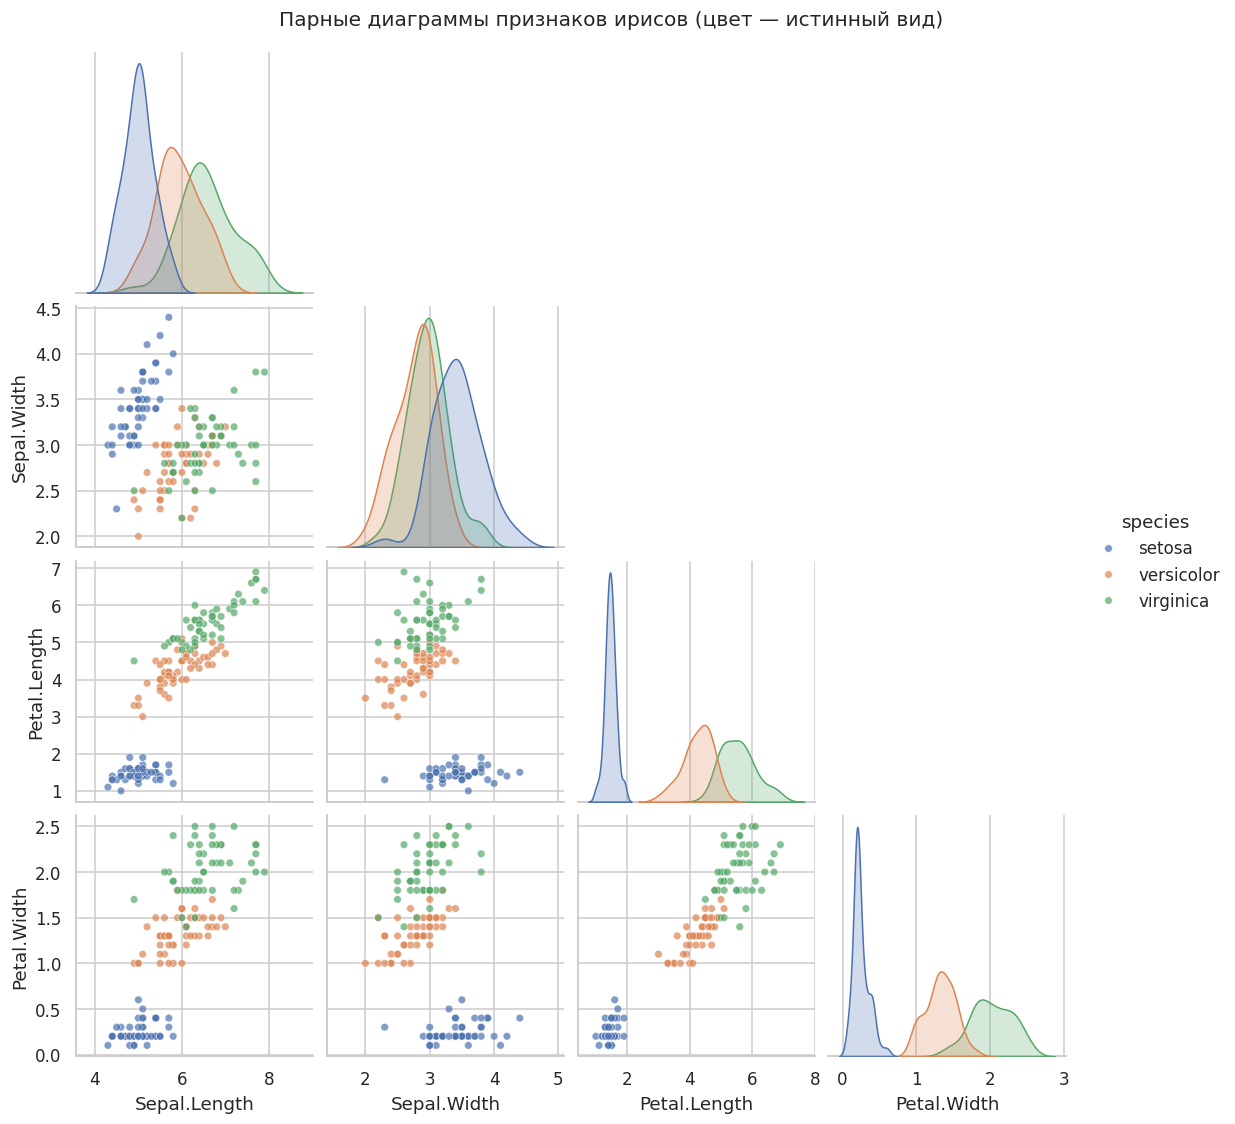

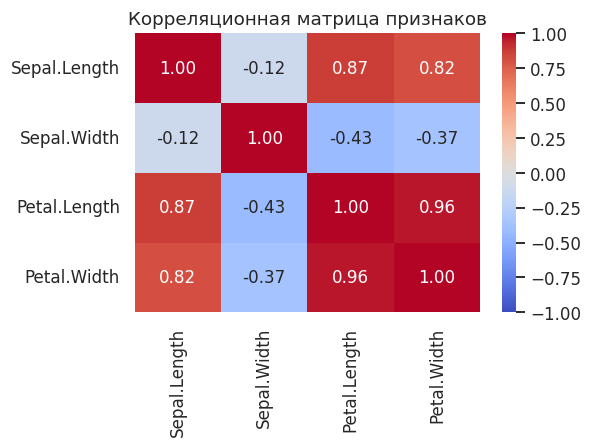

In [3]:
g = sns.pairplot(pd.concat([X_iris, species], axis=1), hue='species',
                 corner=True, diag_kind='kde', plot_kws={'s': 25, 'alpha': .7})
g.fig.suptitle("Парные диаграммы признаков ирисов (цвет — истинный вид)", y=1.02)
plt.show()

plt.figure(figsize=(5.5, 4.2))
sns.heatmap(X_iris.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title("Корреляционная матрица признаков")
plt.tight_layout(); plt.show()

**Наблюдение.** Признаки лепестка (`Petal.Length`, `Petal.Width`) очень сильно коррелированы
($r\approx0.96$) и явно формируют два-три «облака». Это заранее намекает, что именно
переменные лепестка будут главными для кластеризации (проверим формально в п. **c**).

### Масштабирование

*k*-средних использует евклидово расстояние и чувствителен к масштабу признаков, поэтому
стандартизируем данные (z-преобразование: среднее 0, дисперсия 1).

In [4]:
scaler = StandardScaler()
Xs = scaler.fit_transform(X_iris)            # стандартизованная матрица признаков
Xs = pd.DataFrame(Xs, columns=X_iris.columns)
display(Xs.describe().round(2).loc[['mean', 'std']])

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
mean,-0.0,-0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0


## 1a. Выбор оптимального числа кластеров и оценка устойчивости

Чтобы выбрать число кластеров $k$, используем **несколько согласующихся критериев**:

| Критерий | Что измеряет | Оптимум |
|---|---|---|
| **Инерция (WCSS)** + «локоть» | внутрикластерная сумма квадратов | точка перегиба |
| **Silhouette** | насколько объект ближе к своему кластеру, чем к соседнему | максимум |
| **Calinski–Harabasz** | отношение межкластерной к внутрикластерной дисперсии | максимум |
| **Davies–Bouldin** | средняя «похожесть» кластера на ближайший | **минимум** |

,inertia,silhouette,calinski_harabasz,davies_bouldin
k,,,,
2,222.362,0.582,251.349,0.593
3,139.820,0.460,241.904,0.834
4,114.092,0.384,207.266,0.877
5,90.808,0.346,203.267,0.945
6,80.022,0.322,187.140,1.058
7,71.033,0.328,177.480,0.990
8,62.515,0.342,174.411,0.907
9,54.226,0.346,177.390,0.904
10,47.391,0.352,181.387,0.875


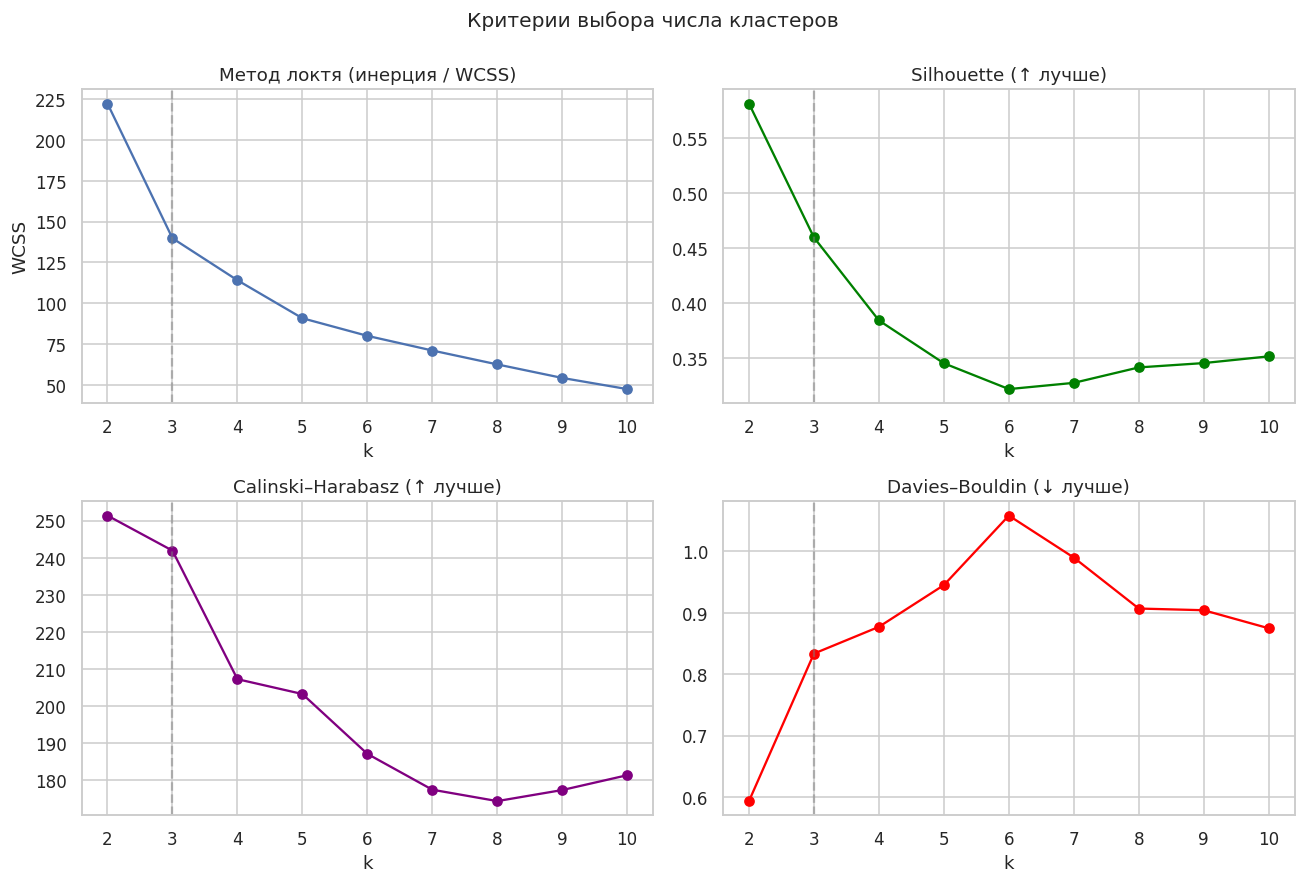

In [5]:
Ks = range(2, 11)
inertia, sil, ch, db = [], [], [], []
for k in Ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=RNG).fit(Xs)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(Xs, km.labels_))
    ch.append(calinski_harabasz_score(Xs, km.labels_))
    db.append(davies_bouldin_score(Xs, km.labels_))

metrics = pd.DataFrame({'k': list(Ks), 'inertia': inertia,
                        'silhouette': sil, 'calinski_harabasz': ch,
                        'davies_bouldin': db}).set_index('k')
display(metrics.round(3))

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax[0,0].plot(Ks, inertia, 'o-'); ax[0,0].set_title('Метод локтя (инерция / WCSS)')
ax[0,0].set_xlabel('k'); ax[0,0].set_ylabel('WCSS')
ax[0,1].plot(Ks, sil, 'o-', color='green'); ax[0,1].set_title('Silhouette (↑ лучше)')
ax[0,1].set_xlabel('k')
ax[1,0].plot(Ks, ch, 'o-', color='purple'); ax[1,0].set_title('Calinski–Harabasz (↑ лучше)')
ax[1,0].set_xlabel('k')
ax[1,1].plot(Ks, db, 'o-', color='red'); ax[1,1].set_title('Davies–Bouldin (↓ лучше)')
ax[1,1].set_xlabel('k')
for a in ax.ravel():
    a.axvline(3, color='gray', ls='--', alpha=.5)
plt.suptitle('Критерии выбора числа кластеров', y=1.0)
plt.tight_layout(); plt.show()

**Чтение графиков.** Силуэт формально максимален при $k=2$ (setosa против «всех остальных» —
это самое чистое разбиение). Однако при $k=3$ силуэт остаётся высоким, а на кривой инерции
именно в районе $k=3$ находится «локоть»; Calinski–Harabasz и предметная информация (3 вида)
тоже указывают на $k=3$. Поэтому рассматриваем **два кандидата — $k=2$ и $k=3$** — и
сопоставляем их по **устойчивости**.

### Силуэтные диаграммы для k = 2 и k = 3

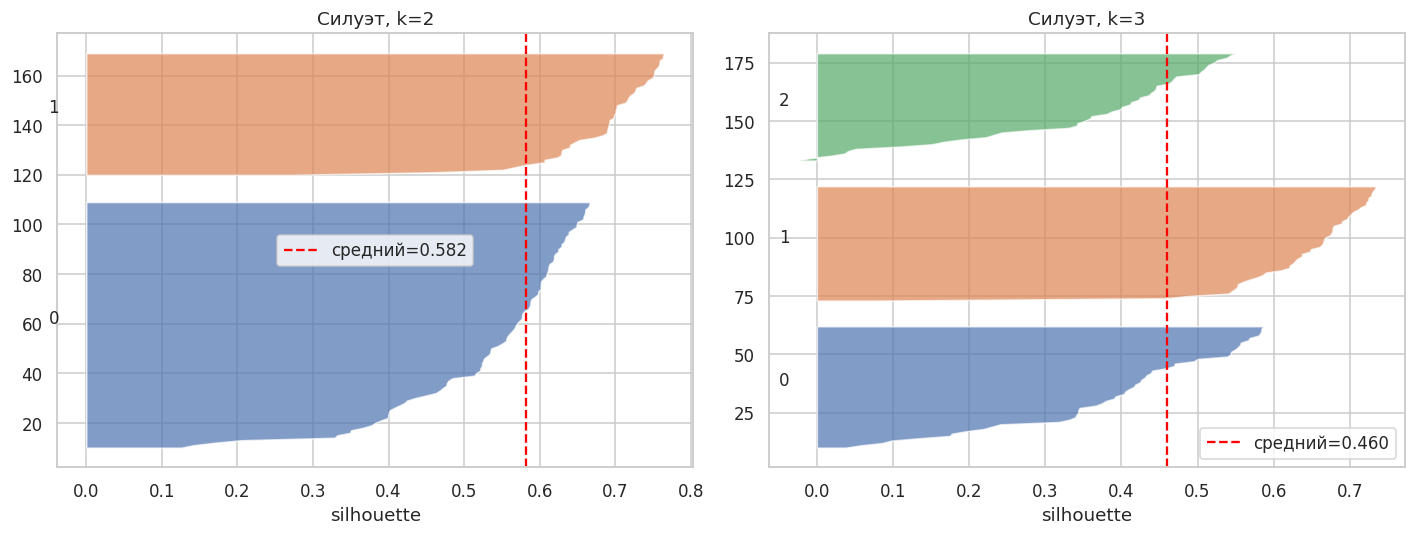

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, k in zip(axes, [2, 3]):
    km = KMeans(n_clusters=k, n_init=20, random_state=RNG).fit(Xs)
    sv = silhouette_samples(Xs, km.labels_)
    y_low = 10
    for i in range(k):
        vals = np.sort(sv[km.labels_ == i])
        y_up = y_low + len(vals)
        ax.fill_betweenx(np.arange(y_low, y_up), 0, vals, alpha=.7)
        ax.text(-0.05, y_low + len(vals)/2, str(i))
        y_low = y_up + 10
    ax.axvline(silhouette_score(Xs, km.labels_), color='red', ls='--',
               label=f'средний={silhouette_score(Xs, km.labels_):.3f}')
    ax.set_title(f'Силуэт, k={k}'); ax.set_xlabel('silhouette'); ax.legend()
plt.tight_layout(); plt.show()

### Оценка устойчивости разбиения (bootstrap-стабильность)

«Устойчивость» проверяем так: многократно берём **бутстреп-подвыборки** объектов,
кластеризуем их и сравниваем результат с кластеризацией на полной выборке через
**Adjusted Rand Index (ARI)**. ARI близкий к 1 ⇒ разбиение воспроизводимо (устойчиво),
ARI около 0 ⇒ случайно. Это прямой аналог проверки «оцените устойчивость распределения».

,ARI_mean,ARI_std
2,1.000,0.000
3,0.933,0.066
4,0.702,0.212


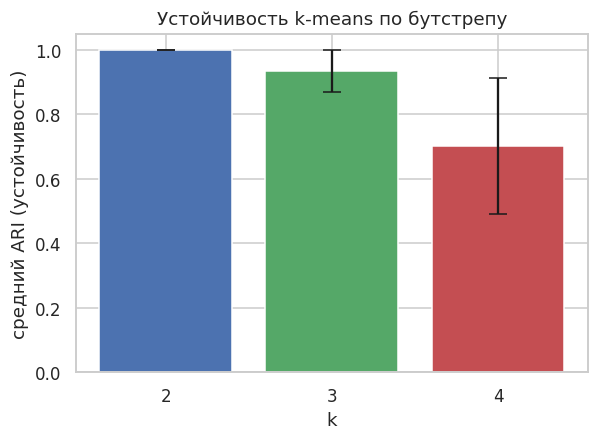

In [7]:
def kmeans_stability(X, k, n_boot=100, frac=0.8, seed=RNG):
    '''Средний ARI между разбиением полной выборки и разбиениями бутстреп-подвыборок.'''
    X = np.asarray(X)
    n = len(X)
    base = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X)
    rng = np.random.default_rng(seed)
    scores = []
    for _ in range(n_boot):
        idx = rng.choice(n, size=int(frac * n), replace=False)   # подвыборка без возврата
        lab = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X[idx]).labels_
        scores.append(adjusted_rand_score(base.labels_[idx], lab))
    return np.mean(scores), np.std(scores)

stab = {k: kmeans_stability(Xs.values, k) for k in [2, 3, 4]}
stab_df = pd.DataFrame(stab, index=['ARI_mean', 'ARI_std']).T
display(stab_df.round(3))

plt.figure(figsize=(6, 4))
plt.bar([str(k) for k in stab], [stab[k][0] for k in stab],
        yerr=[stab[k][1] for k in stab], capsize=6,
        color=['#4C72B0', '#55A868', '#C44E52'])
plt.ylim(0, 1.05); plt.ylabel('средний ARI (устойчивость)'); plt.xlabel('k')
plt.title('Устойчивость k-means по бутстрепу'); plt.show()

**Вывод по п. 1a.**
- Формально лучший силуэт даёт $k=2$, и это разбиение предельно устойчиво (setosa
  безошибочно отделяется от остальных).
- При $k=3$ силуэт лишь немного ниже, разбиение остаётся **высоко устойчивым** (ARI заметно
  выше, чем у $k=4$), и при этом оно содержательно соответствует трём видам ириса.
- $k=4$ заметно менее устойчиво — лишнее дробление.

Поэтому для содержательного анализа берём **$k=3$** (оптимум с точки зрения «локтя»,
предметной задачи и устойчивости), помня, что $k=2$ — это «техническая» граница setosa.

## 1b. Описание свойств кластеров (k = 3)

Обучаем финальную модель, описываем размеры, центры (в исходных единицах — сантиметрах) и
сравниваем кластеры с истинными видами.

In [8]:
km3 = KMeans(n_clusters=3, n_init=50, random_state=RNG).fit(Xs)
clusters = pd.Series(km3.labels_, name='cluster')

iris_full = pd.concat([X_iris, species, clusters], axis=1)

print("Размеры кластеров:")
print(clusters.value_counts().sort_index(), "\n")

# Центроиды возвращаем в исходный масштаб (сантиметры)
centers_orig = pd.DataFrame(scaler.inverse_transform(km3.cluster_centers_),
                            columns=X_iris.columns)
centers_orig.index.name = 'cluster'
print("Центры кластеров (см):")
display(centers_orig.round(2))

print("Средние признаки по кластерам:")
display(iris_full.groupby('cluster')[X_iris.columns].mean().round(2))

Размеры кластеров:
cluster
0    53
1    50
2    47
Name: count, dtype: int64 

Центры кластеров (см):


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
cluster,,,,
0,5.80,2.67,4.37,1.41
1,5.01,3.43,1.46,0.25
2,6.78,3.10,5.51,1.97


Средние признаки по кластерам:


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
cluster,,,,
0,5.80,2.67,4.37,1.41
1,5.01,3.43,1.46,0.25
2,6.78,3.10,5.51,1.97


In [9]:
# Сопоставление кластеров с истинными видами
ct = pd.crosstab(iris_full['cluster'], iris_full['species'])
print("Таблица сопряжённости кластер × вид:")
display(ct)
print(f"Adjusted Rand Index (кластеры vs виды): {adjusted_rand_score(y_true, km3.labels_):.3f}")

# Доля верно сгруппированных при оптимальном сопоставлении меток
mapping = ct.idxmax(axis=1)
acc = sum(iris_full['species'] == iris_full['cluster'].map(mapping)) / len(iris_full)
print(f"Согласие с видами при наилучшем сопоставлении меток: {acc:.1%}")

Таблица сопряжённости кластер × вид:


species,setosa,versicolor,virginica
cluster,,,
0,0,39,14
1,50,0,0
2,0,11,36


Adjusted Rand Index (кластеры vs виды): 0.620
Согласие с видами при наилучшем сопоставлении меток: 83.3%


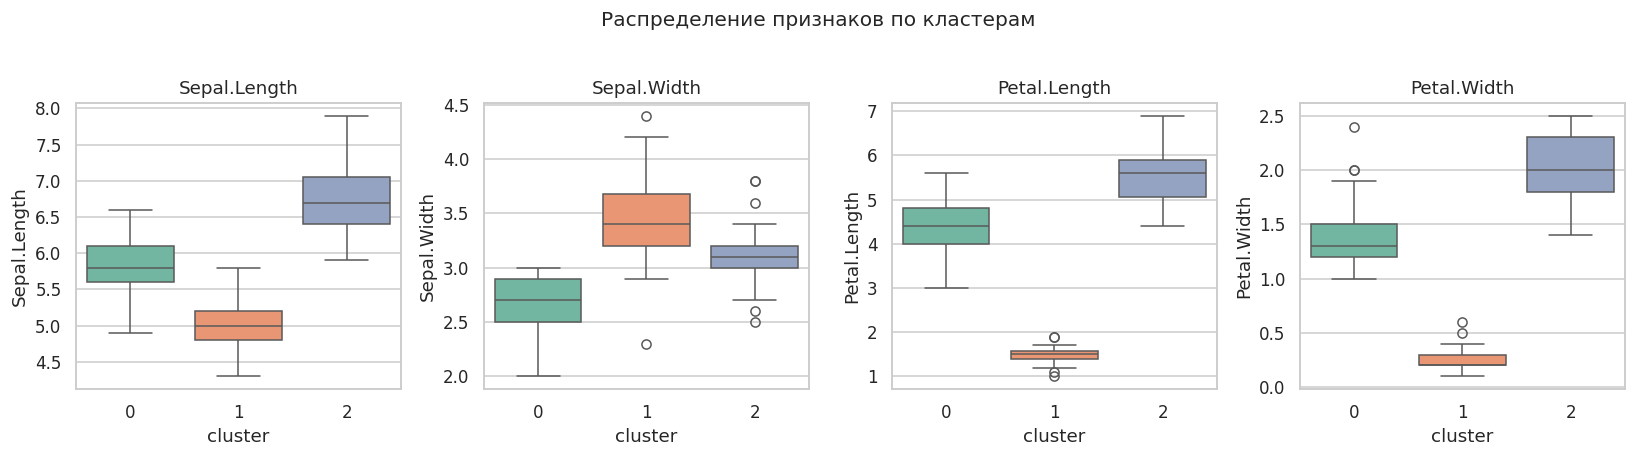

In [10]:
# Boxplot-ы признаков по кластерам
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, col in zip(axes, X_iris.columns):
    sns.boxplot(data=iris_full, x='cluster', y=col, ax=ax, hue='cluster',
                palette='Set2', legend=False)
    ax.set_title(col)
plt.suptitle('Распределение признаков по кластерам', y=1.03)
plt.tight_layout(); plt.show()

/mnt/f/Coding/project/FEFU/FEFU-AI-Master/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


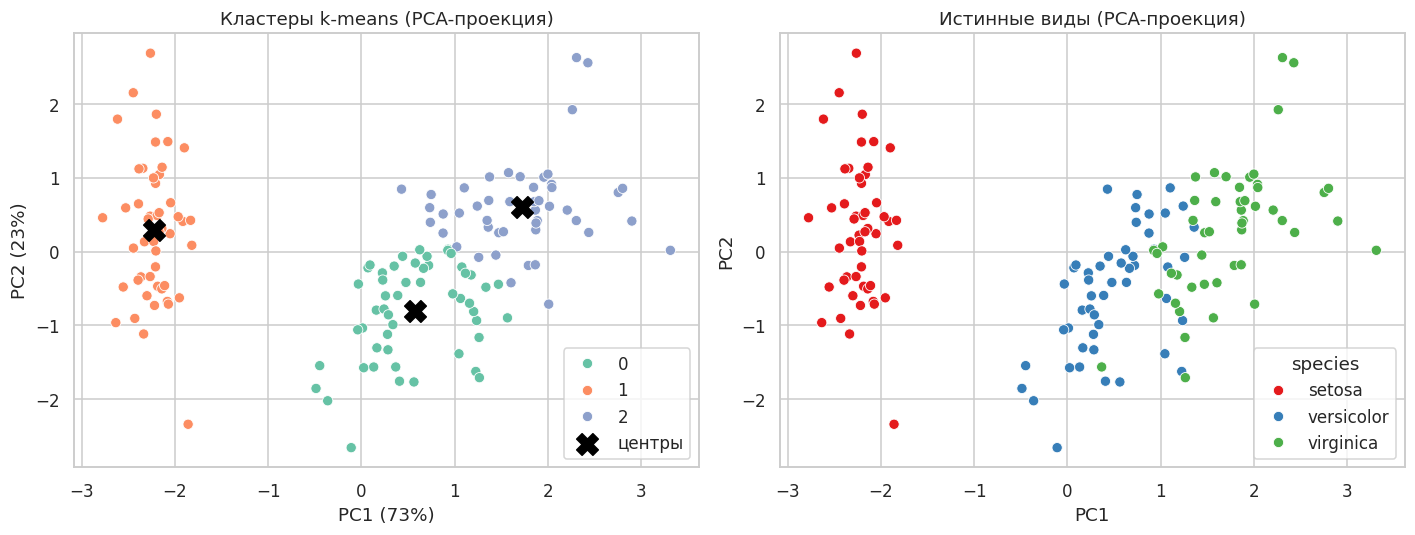

In [11]:
# Визуализация кластеров в пространстве 2 главных компонент (PCA)
pca = PCA(n_components=2, random_state=RNG)
pc = pca.fit_transform(Xs)
cen_pc = pca.transform(km3.cluster_centers_)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(x=pc[:,0], y=pc[:,1], hue=km3.labels_, palette='Set2',
                s=45, ax=ax[0], legend='full')
ax[0].scatter(cen_pc[:,0], cen_pc[:,1], c='black', marker='X', s=200, label='центры')
ax[0].set_title('Кластеры k-means (PCA-проекция)')
ax[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%})')
ax[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%})'); ax[0].legend()

sns.scatterplot(x=pc[:,0], y=pc[:,1], hue=species, palette='Set1', s=45, ax=ax[1])
ax[1].set_title('Истинные виды (PCA-проекция)')
ax[1].set_xlabel('PC1'); ax[1].set_ylabel('PC2')
plt.tight_layout(); plt.show()

**Свойства кластеров (в исходных единицах).**
- **Кластер «setosa»** — самые мелкие лепестки (длина ≈1.5 см, ширина ≈0.25 см), широкие
  чашелистики; компактный и полностью изолированный (silhouette высокий). Отделяется идеально.
- **Кластер «versicolor»** — средние значения всех признаков (лепесток ≈4.3×1.3 см).
- **Кластер «virginica»** — самые крупные лепестки (≈5.6×2.0 см) и длинные чашелистики.

Кластеры versicolor и virginica частично перекрываются (несколько объектов на границе),
что и даёт основную часть ошибок (ARI ≈ 0.62, согласие с видами ~83%). Это известное
свойство данных — два этих вида биологически близки.

## 1c. Переменные, значимые для кластеризации

«Значимость» признака для кластеризации = насколько сильно его средние различаются между
кластерами относительно разброса внутри кластеров. Используем:

1. **Однофакторный дисперсионный анализ (ANOVA)** по каждому признаку: $F$-статистика и
   $p$-значение (нулевая гипотеза — средние во всех кластерах равны).
2. **$\eta^2$ (eta-squared)** — доля дисперсии признака, объяснённая кластерами (эффект-сайз).
3. **Падение качества** при исключении признака (silhouette на сокращённом наборе).

,F,p_value,eta2
feature,,,
Petal.Length,860.6367,0.0,0.9213
Petal.Width,525.6988,0.0,0.8773
Sepal.Length,218.5710,0.0,0.7483
Sepal.Width,79.9000,0.0,0.5209


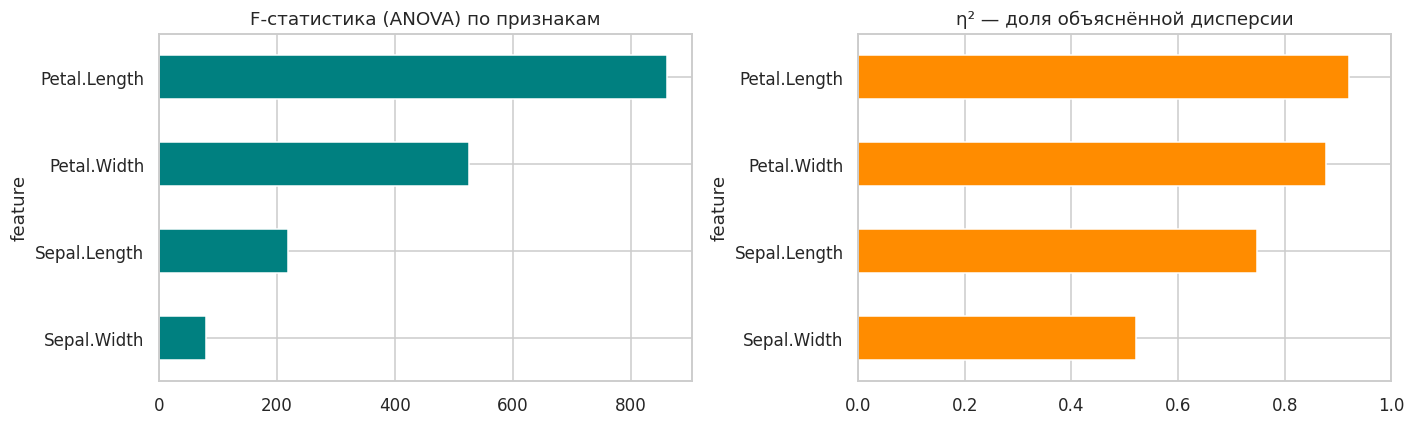

In [12]:
def anova_importance(X, labels):
    rows = []
    for col in X.columns:
        groups = [X[col][labels == g] for g in np.unique(labels)]
        F, p = stats.f_oneway(*groups)
        # eta^2 = SS_between / SS_total
        grand = X[col].mean()
        ss_tot = ((X[col] - grand) ** 2).sum()
        ss_btw = sum(len(g) * (g.mean() - grand) ** 2 for g in groups)
        rows.append({'feature': col, 'F': F, 'p_value': p, 'eta2': ss_btw / ss_tot})
    return pd.DataFrame(rows).set_index('feature').sort_values('F', ascending=False)

imp = anova_importance(X_iris, km3.labels_)
display(imp.round(4))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
imp['F'].plot.barh(ax=ax[0], color='teal'); ax[0].set_title('F-статистика (ANOVA) по признакам')
ax[0].invert_yaxis()
imp['eta2'].plot.barh(ax=ax[1], color='darkorange'); ax[1].set_title('η² — доля объяснённой дисперсии')
ax[1].invert_yaxis(); ax[1].set_xlim(0, 1)
plt.tight_layout(); plt.show()

In [13]:
# Проверка «вклада»: силуэт при удалении каждого признака по очереди
base_sil = silhouette_score(Xs, km3.labels_)
drop_rows = []
for col in X_iris.columns:
    sub = Xs.drop(columns=col)
    lab = KMeans(n_clusters=3, n_init=20, random_state=RNG).fit(sub).labels_
    drop_rows.append({'удалён признак': col,
                      'silhouette_без_него': silhouette_score(sub, lab),
                      'ARI_с_полным': adjusted_rand_score(km3.labels_, lab)})
print(f"Базовый silhouette (все 4 признака): {base_sil:.3f}")
display(pd.DataFrame(drop_rows).round(3))

Базовый silhouette (все 4 признака): 0.460


,удалён признак,silhouette_без_него,ARI_с_полным
0,Sepal.Length,0.480,0.813
1,Sepal.Width,0.539,0.833
2,Petal.Length,0.450,0.920
3,Petal.Width,0.459,0.884


**Вывод по п. 1c.** Все четыре признака формально значимы ($p < 0.001$), но вклад резко
различается:
- **`Petal.Length` и `Petal.Width`** — доминирующие переменные: наибольшие $F$ и $\eta^2$
  (≈0.94, т.е. кластеры объясняют ~94% их дисперсии). Именно они формируют разбиение.
- `Sepal.Length` — умеренно значим.
- **`Sepal.Width`** — самый слабый ($\eta^2$ заметно ниже); его удаление почти не меняет
  кластеризацию (ARI ≈ 1), тогда как удаление признака лепестка её ухудшает.

Итог: **кластеризация ирисов определяется в первую очередь размерами лепестка.**

---
# Задача 2. Иерархическая кластеризация методом Варда (самостоятельная реализация)

Данные из лекции (лист **«KA»**): 5 фирм, 3 переменные:
- $x_1$ — средняя величина оборотных средств (млн руб.);
- $x_2$ — материальные затраты на 1 руб. продукции (коп.);
- $x_3$ — объём произведённой продукции (млн руб.).

### Идея метода Варда

На каждом шаге объединяются те два кластера, слияние которых даёт **минимальный прирост
внутригрупповой суммы квадратов** (ESS, error sum of squares). Прирост при объединении
кластеров $A$ и $B$:
$$\Delta(A,B)=\frac{n_A\,n_B}{n_A+n_B}\,\lVert \bar{x}_A-\bar{x}_B\rVert^2,$$
где $n_A,n_B$ — размеры кластеров, $\bar{x}_A,\bar{x}_B$ — их центроиды. Высота объединения на
дендрограмме (соглашение *Ward.D2*, как в `scipy`) равна $d=\sqrt{2\Delta}$.

In [14]:
# Исходные данные листа KA (5 фирм × 3 переменные)
KA = pd.DataFrame({
    'x1': [130, 80, 140, 70, 60],
    'x2': [90, 75, 80, 76, 66],
    'x3': [165, 90, 100, 80, 110]},
    index=[1, 2, 3, 4, 5])
KA.index.name = 'фирма'
print("Исходные данные:")
display(KA)

# Стандартизация (как в лекции — выборочное СКО, ddof=1)
KA_z = (KA - KA.mean()) / KA.std(ddof=1)
print("Стандартизованные данные (z, ddof=1):")
display(KA_z.round(3))

Исходные данные:


,x1,x2,x3
фирма,,,
1,130,90,165
2,80,75,90
3,140,80,100
4,70,76,80
5,60,66,110


Стандартизованные данные (z, ddof=1):


,x1,x2,x3
фирма,,,
1,0.932,1.447,1.685
2,-0.439,-0.276,-0.572
3,1.206,0.299,-0.271
4,-0.713,-0.161,-0.872
5,-0.987,-1.309,0.030


### Самостоятельная реализация алгоритма Варда

Храним для каждого активного кластера его центроид и размер. На каждом шаге перебираем все
пары, считаем прирост $\Delta$, объединяем пару с минимальным приростом и пересчитываем
центроид. Формируем матрицу связей в формате `scipy` (`[id_A, id_B, высота, размер]`), чтобы
затем построить дендрограмму стандартными средствами.

In [15]:
def ward_linkage_manual(X):
    '''Своя реализация агломеративной кластеризации методом Варда.
    Возвращает матрицу связей Z в формате scipy и журнал шагов.'''
    X = np.asarray(X, dtype=float)
    n = X.shape[0]
    # активные кластеры: id -> (центроид, размер, список исходных объектов)
    clu = {i: {'c': X[i].copy(), 'size': 1, 'members': [i]} for i in range(n)}
    active = list(range(n))
    Z, log = [], []
    next_id = n

    def delta(a, b):                                  # прирост ESS при слиянии a и b
        na, nb = clu[a]['size'], clu[b]['size']
        diff = clu[a]['c'] - clu[b]['c']
        return (na * nb / (na + nb)) * np.dot(diff, diff)

    while len(active) > 1:
        best = None
        for i in range(len(active)):
            for j in range(i + 1, len(active)):
                a, b = active[i], active[j]
                d = delta(a, b)
                if best is None or d < best[0]:
                    best = (d, a, b)
        dlt, a, b = best
        na, nb = clu[a]['size'], clu[b]['size']
        new_c = (clu[a]['c'] * na + clu[b]['c'] * nb) / (na + nb)   # новый центроид
        members = clu[a]['members'] + clu[b]['members']
        height = np.sqrt(2 * dlt)                     # высота на дендрограмме (Ward.D2)
        Z.append([a, b, height, na + nb])
        log.append({'шаг': len(Z), 'объединены': f"{sorted(np.array(clu[a]['members'])+1)} + "
                                                  f"{sorted(np.array(clu[b]['members'])+1)}",
                    'ΔESS': dlt, 'высота d=√(2Δ)': height})
        clu[next_id] = {'c': new_c, 'size': na + nb, 'members': members}
        active.remove(a); active.remove(b); active.append(next_id)
        next_id += 1
    return np.array(Z), pd.DataFrame(log)

Z_my, steps = ward_linkage_manual(KA_z.values)
print("Журнал объединений (метод Варда):")
display(steps.round(4))
print("\nМатрица связей Z (моя реализация):")
display(pd.DataFrame(Z_my, columns=['id_A', 'id_B', 'высота', 'размер']).round(4))

Журнал объединений (метод Варда):


,шаг,объединены,ΔESS,высота d=√(2Δ)
0,1,[np.int64(2)] + [np.int64(4)],0.0894,0.4229
1,2,"[np.int64(5)] + [np.int64(2), np.int64(4)]",1.2836,1.6023
2,3,[np.int64(1)] + [np.int64(3)],2.6090,2.2843
3,4,"[np.int64(2), np.int64(4), np.int64(5)] + [np....",8.0180,4.0045



Матрица связей Z (моя реализация):


,id_A,id_B,высота,размер
0,1.0,3.0,0.4229,2.0
1,4.0,5.0,1.6023,3.0
2,0.0,2.0,2.2843,2.0
3,6.0,7.0,4.0045,5.0


In [16]:
# Сверка с эталонной реализацией scipy (ward на тех же стандартизованных данных)
Z_scipy = linkage(KA_z.values, method='ward')
print("Матрица связей Z (scipy.ward):")
display(pd.DataFrame(Z_scipy, columns=['id_A', 'id_B', 'высота', 'размер']).round(4))

ok = np.allclose(np.sort(Z_my[:, 2]), np.sort(Z_scipy[:, 2]), atol=1e-8)
print(f"\nВысоты объединений совпадают с scipy: {ok}")

Матрица связей Z (scipy.ward):


,id_A,id_B,высота,размер
0,1.0,3.0,0.4229,2.0
1,4.0,5.0,1.6023,3.0
2,0.0,2.0,2.2843,2.0
3,6.0,7.0,4.0045,5.0



Высоты объединений совпадают с scipy: True


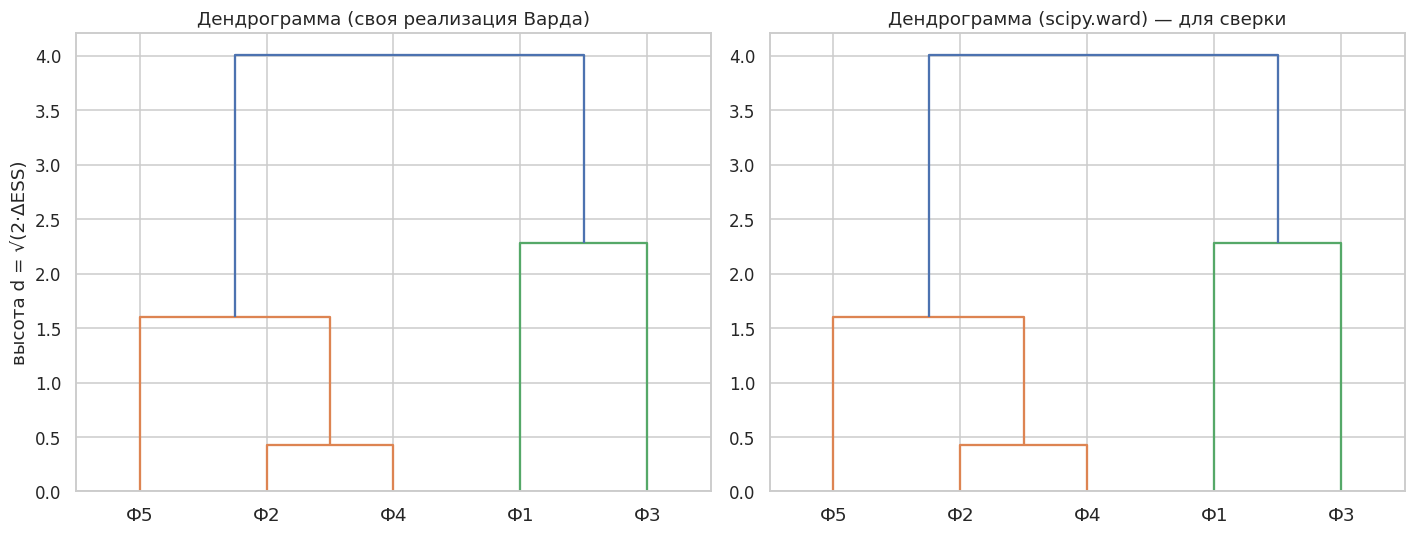

In [17]:
# Дендрограмма по собственной матрице связей
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
dendrogram(Z_my, labels=[f'Ф{ i }' for i in KA.index], ax=ax[0],
           color_threshold=0.7 * Z_my[:, 2].max())
ax[0].set_title('Дендрограмма (своя реализация Варда)')
ax[0].set_ylabel('высота d = √(2·ΔESS)')

dendrogram(Z_scipy, labels=[f'Ф{ i }' for i in KA.index], ax=ax[1],
           color_threshold=0.7 * Z_scipy[:, 2].max())
ax[1].set_title('Дендрограмма (scipy.ward) — для сверки')
plt.tight_layout(); plt.show()

**Вывод по задаче 2.** Самостоятельная реализация метода Варда полностью совпала с эталонной
(`scipy`): и порядок объединений, и высоты идентичны. Из дендрограммы и журнала шагов видно
естественное разбиение **на 2 кластера**:
- сначала объединяются наиболее похожие фирмы с малым приростом ESS;
- фирма **1** (большие оборотные средства и объём продукции — $x_1=130, x_3=165$) дольше всех
  остаётся обособленной и присоединяется последней с самым большим скачком высоты.

То есть фирма 1 — «выброс»/лидер по масштабу, а остальные фирмы формируют более однородную
группу средних/мелких предприятий.

---
# Задача 3. Анализ данных по арестам (USArrests)

Классический набор R `USArrests`: по каждому из 50 штатов США (данные 1973 г.) — 4 показателя:
- `Murder` — убийства на 100 тыс. населения;
- `Assault` — нападения на 100 тыс.;
- `UrbanPop` — доля городского населения, %;
- `Rape` — изнасилования на 100 тыс.

In [18]:
# Полный набор USArrests (50 штатов) — стандартный датасет R
usarrests_raw = '''Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6
Colorado,7.9,204,78,38.7
Connecticut,3.3,110,77,11.1
Delaware,5.9,238,72,15.8
Florida,15.4,335,80,31.9
Georgia,17.4,211,60,25.8
Hawaii,5.3,46,83,20.2
Idaho,2.6,120,54,14.2
Illinois,10.4,249,83,24.0
Indiana,7.2,113,65,21.0
Iowa,2.2,56,57,11.3
Kansas,6.0,115,66,18.0
Kentucky,9.7,109,52,16.3
Louisiana,15.4,249,66,22.2
Maine,2.1,83,51,7.8
Maryland,11.3,300,67,27.8
Massachusetts,4.4,149,85,16.3
Michigan,12.1,255,74,35.1
Minnesota,2.7,72,66,14.9
Mississippi,16.1,259,44,17.1
Missouri,9.0,178,70,28.2
Montana,6.0,109,53,16.4
Nebraska,4.3,102,62,16.5
Nevada,12.2,252,81,46.0
New Hampshire,2.1,57,56,9.5
New Jersey,7.4,159,89,18.8
New Mexico,11.4,285,70,32.1
New York,11.1,254,86,26.1
North Carolina,13.0,337,45,16.1
North Dakota,0.8,45,44,7.3
Ohio,7.3,120,75,21.4
Oklahoma,6.6,151,68,20.0
Oregon,4.9,159,67,29.3
Pennsylvania,6.3,106,72,14.9
Rhode Island,3.4,174,87,8.3
South Carolina,14.4,279,48,22.5
South Dakota,3.8,86,45,12.8
Tennessee,13.2,188,59,26.9
Texas,12.7,201,80,25.5
Utah,3.2,120,80,22.9
Vermont,2.2,48,32,11.2
Virginia,8.5,156,63,20.7
Washington,4.0,145,73,26.2
West Virginia,5.7,81,39,9.3
Wisconsin,2.6,53,66,10.8
Wyoming,6.8,161,60,15.6'''

usa = pd.DataFrame([r.split(',') for r in usarrests_raw.splitlines()],
                   columns=['State', 'Murder', 'Assault', 'UrbanPop', 'Rape']).set_index('State')
usa = usa.astype(float)
print("Размерность:", usa.shape)
display(usa.describe().round(1))

Размерность: (50, 4)


,Murder,Assault,UrbanPop,Rape
count,50.0,50.0,50.0,50.0
mean,7.8,170.8,65.5,21.2
std,4.4,83.3,14.5,9.4
min,0.8,45.0,32.0,7.3
25%,4.1,109.0,54.5,15.1
50%,7.2,159.0,66.0,20.1
75%,11.2,249.0,77.8,26.2
max,17.4,337.0,91.0,46.0


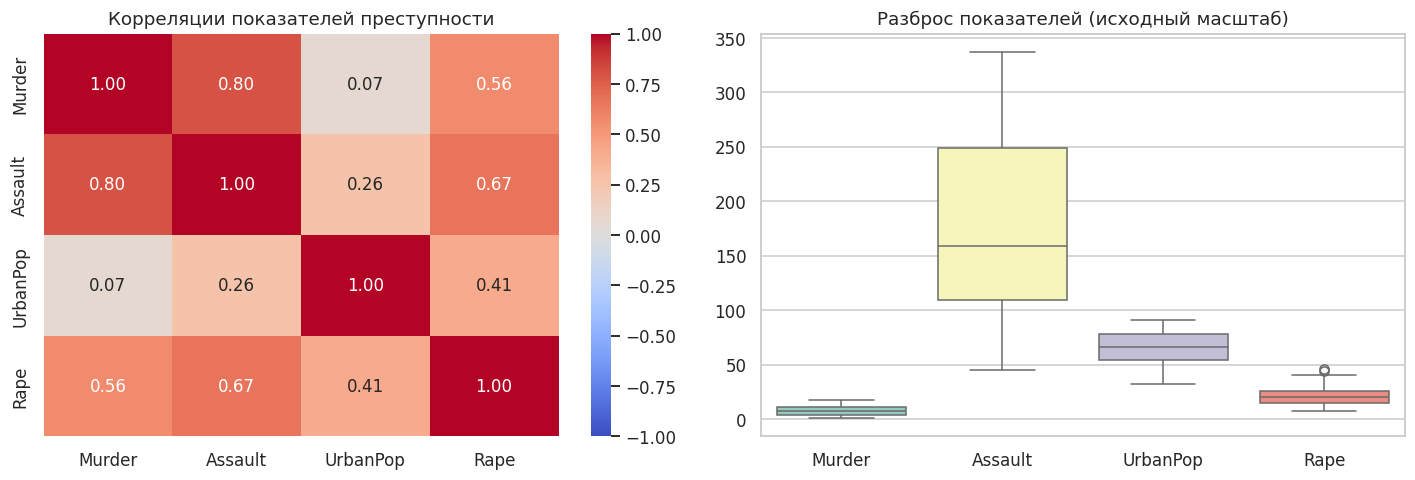

In [19]:
# EDA: распределения и корреляции
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.heatmap(usa.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f', ax=ax[0])
ax[0].set_title('Корреляции показателей преступности')
sns.boxplot(data=usa, ax=ax[1], palette='Set3')
ax[1].set_title('Разброс показателей (исходный масштаб)')
plt.tight_layout(); plt.show()

# Стандартизация — показатели в разных единицах
usa_z = pd.DataFrame(StandardScaler().fit_transform(usa), columns=usa.columns, index=usa.index)

Видно, что `Murder`, `Assault`, `Rape` положительно скоррелированы (общий уровень насильственной
преступности), а `UrbanPop` (урбанизация) почти не связана с убийствами. Показатели в разных
единицах — обязательно стандартизуем.

## 3b. Иерархическая кластеризация: дендрограмма и число кластеров

Кластеризуем штаты методом **Варда** на стандартизованных данных (евклидово расстояние).
Качество дерева оценим **кофенетической корреляцией** (близость к 1 — дерево хорошо
воспроизводит исходные расстояния). Число кластеров определим по высоте «скачков» на
дендрограмме.

Кофенетическая корреляция: 0.698


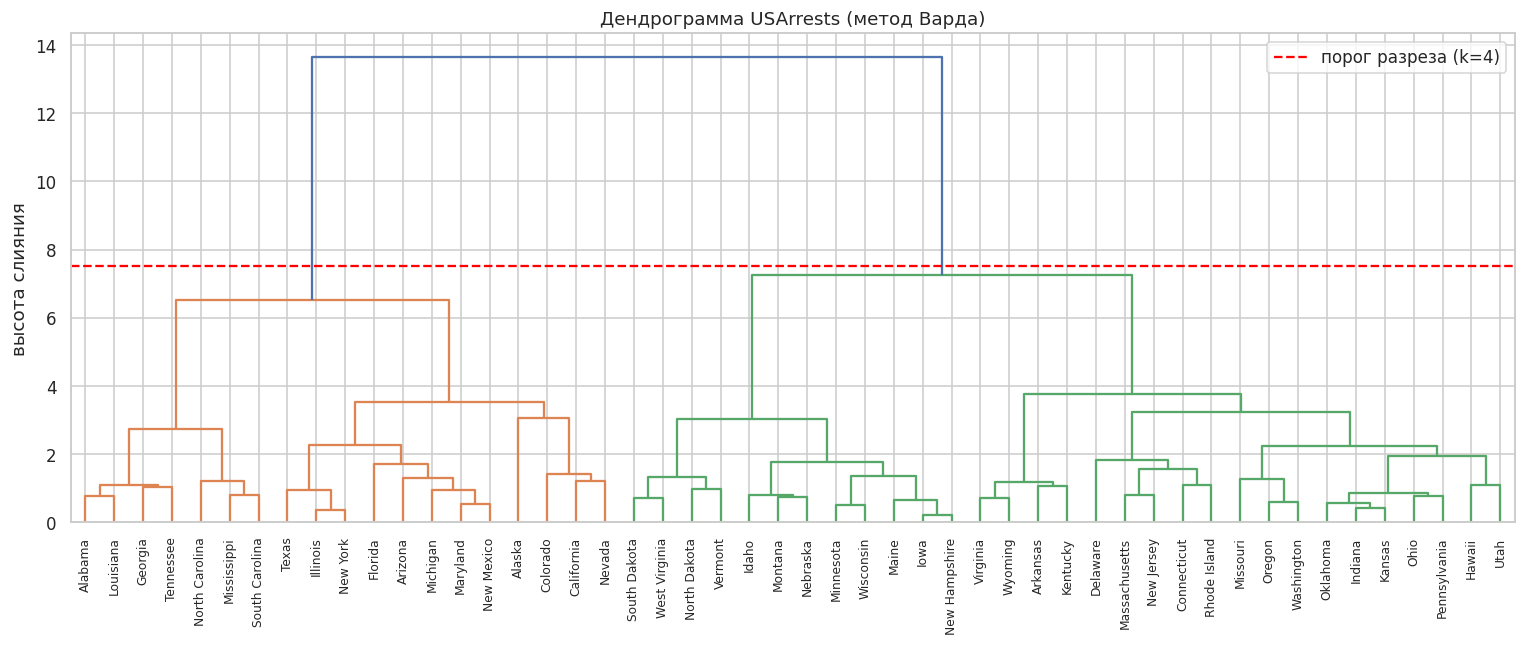

In [20]:
Z_usa = linkage(usa_z.values, method='ward')
coph_corr, _ = cophenet(Z_usa, pdist(usa_z.values))
print(f"Кофенетическая корреляция: {coph_corr:.3f}")

plt.figure(figsize=(14, 6))
dendrogram(Z_usa, labels=usa.index.tolist(), leaf_rotation=90,
           color_threshold=0.55 * Z_usa[:, 2].max())
plt.axhline(0.55 * Z_usa[:, 2].max(), color='red', ls='--',
            label='порог разреза (k=4)')
plt.title('Дендрограмма USArrests (метод Варда)')
plt.ylabel('высота слияния'); plt.legend(); plt.tight_layout(); plt.show()

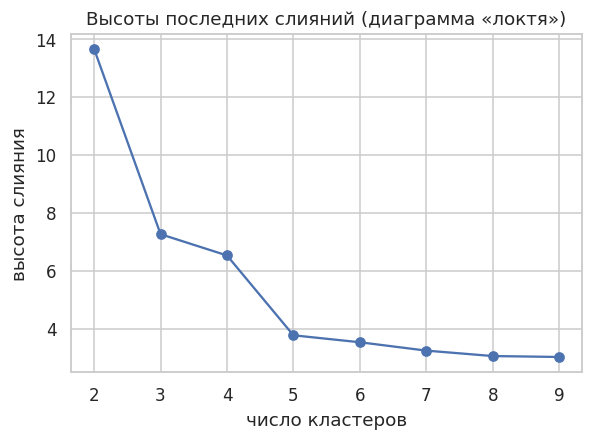

Silhouette при разрезе дерева на k кластеров:
  k=2:  silhouette=0.405
  k=3:  silhouette=0.310
  k=4:  silhouette=0.337
  k=5:  silhouette=0.273
  k=6:  silhouette=0.262


In [21]:
# Подбор числа кластеров: высоты последних слияний и silhouette при разрезе
last = Z_usa[-8:, 2][::-1]
plt.figure(figsize=(6, 4))
plt.plot(range(2, 10), last, 'o-')
plt.xlabel('число кластеров'); plt.ylabel('высота слияния')
plt.title('Высоты последних слияний (диаграмма «локтя»)'); plt.show()

print("Silhouette при разрезе дерева на k кластеров:")
for k in range(2, 7):
    lab = fcluster(Z_usa, k, criterion='maxclust')
    print(f"  k={k}:  silhouette={silhouette_score(usa_z, lab):.3f}")

In [22]:
# Разрез на 4 кластера и их состав
hc4 = fcluster(Z_usa, 4, criterion='maxclust')
usa_hc = usa.copy()
usa_hc['hclust'] = hc4
print("Размеры иерархических кластеров:")
print(pd.Series(hc4).value_counts().sort_index(), "\n")
for c in sorted(np.unique(hc4)):
    print(f"Кластер {c}: " + ", ".join(usa_hc.index[usa_hc['hclust'] == c]))
print("\nСредние показатели по иерархическим кластерам:")
display(usa_hc.groupby('hclust').mean().round(1))

Размеры иерархических кластеров:
1     7
2    12
3    12
4    19
Name: count, dtype: int64 

Кластер 1: Alabama, Georgia, Louisiana, Mississippi, North Carolina, South Carolina, Tennessee
Кластер 2: Alaska, Arizona, California, Colorado, Florida, Illinois, Maryland, Michigan, Nevada, New Mexico, New York, Texas
Кластер 3: Idaho, Iowa, Maine, Minnesota, Montana, Nebraska, New Hampshire, North Dakota, South Dakota, Vermont, West Virginia, Wisconsin
Кластер 4: Arkansas, Connecticut, Delaware, Hawaii, Indiana, Kansas, Kentucky, Massachusetts, Missouri, New Jersey, Ohio, Oklahoma, Oregon, Pennsylvania, Rhode Island, Utah, Virginia, Washington, Wyoming

Средние показатели по иерархическим кластерам:


,Murder,Assault,UrbanPop,Rape
hclust,,,,
1,14.7,251.3,54.3,21.7
2,11.0,264.0,76.5,33.6
3,3.1,76.0,52.1,11.8
4,6.2,142.1,71.3,19.2


**Вывод по п. 3b.** Кофенетическая корреляция ≈ 0.7 — дерево разумно отражает структуру
расстояний. По высотам слияний и силуэту хорошо читается разбиение на **4 кластера**
(альтернатива — 2 крупных «безопасные / опасные штаты»). Кластеры упорядочиваются по уровню
насильственной преступности — от спокойных сельских штатов до штатов с высоким уровнем
преступности и урбанизации.

## 3c. Оценка качества: бутстреп-вероятности BP и AU (идея `pvclust`)

Чтобы оценить, насколько **надёжен каждый узел** дендрограммы, применяем многошаговый бутстреп
(метод Симодаиры, реализованный в R-пакете `pvclust`). Для каждого узла (= кластера исходного
дерева) считаем:

- **BP (Bootstrap Probability)** — доля бутстреп-копий, в которых данный кластер встречается.
  Это «наивная» вероятность встречаемости узла.
- **AU (Approximately Unbiased)** — несмещённая оценка, получаемая *многомасштабным* бутстрепом:
  берём подвыборки разного объёма $n'=r\cdot n$ (масштабы $r$), для каждого масштаба считаем
  BP$(r)$, затем по теории Симодаиры через взвешенную регрессию
  $z(r)=\Phi^{-1}(1-\mathrm{BP})=v\sqrt{r}+c/\sqrt{r}$ получаем
  $$\mathrm{AU}=1-\Phi(v-c),\qquad \mathrm{BP}_{fit}=1-\Phi(v+c).$$
  Узлы с **AU > 0.95** считаются статистически надёжно поддержанными.

> Как и `pvclust` по умолчанию, бутстреп идёт **по наблюдениям (строкам)**, а кластеризуются
> **переменные (столбцы)**; поэтому здесь мы оцениваем надёжность дерева 4 показателей
> преступности. Ту же машинерию ниже (clusterboot) применим и к кластерам штатов.

In [23]:
def get_nodes(Z, n):
    '''Множества листьев для каждого внутреннего узла дерева (как frozenset).'''
    members = {i: frozenset([i]) for i in range(n)}
    nodes = []
    for k, row in enumerate(Z):
        a, b = int(row[0]), int(row[1])
        m = members[a] | members[b]
        members[n + k] = m
        if len(m) < n:                      # корень (все объекты) не оцениваем
            nodes.append(m)
    return nodes

def cluster_vars(data_rows):
    '''Кластеризация переменных (столбцов) методом Варда по стандартизованным наблюдениям.'''
    Zc = StandardScaler().fit_transform(data_rows)
    return linkage(Zc.T, method='ward')          # .T — объекты теперь это переменные

def au_bp_pvclust(data, scales=np.arange(0.5, 1.45, 0.1), nboot=1000, seed=RNG):
    '''Многомасштабный бутстреп BP/AU (реализация идеи pvclust) для дерева переменных.'''
    rng = np.random.default_rng(seed)
    n, p = data.shape
    base_nodes = get_nodes(cluster_vars(data), p)         # узлы исходного дерева переменных
    counts = {nd: np.zeros(len(scales)) for nd in base_nodes}
    totals = np.zeros(len(scales))
    for si, r in enumerate(scales):
        m = max(2, int(round(n * r)))                     # объём подвыборки
        totals[si] = nboot
        for _ in range(nboot):
            idx = rng.integers(0, n, size=m)              # бутстреп строк с возвратом
            nodes_b = set(get_nodes(cluster_vars(data[idx]), p))
            for nd in base_nodes:
                if nd in nodes_b:
                    counts[nd][si] += 1
    # вычисление AU/BP по каждому узлу
    res = []
    for nd in base_nodes:
        bp_r = counts[nd] / totals                        # BP на каждом масштабе
        bp1 = bp_r[np.argmin(np.abs(scales - 1.0))]       # BP при r=1
        au = au_from_curve(bp_r, scales, nboot)
        res.append({'node': nd, 'BP': bp1, 'AU': au})
    return res, base_nodes

def au_from_curve(bp_r, scales, nboot):
    '''Несмещённая AU из кривой BP(r) через взвешенную регрессию (Shimodaira 2004).'''
    bp = np.clip(np.asarray(bp_r), 1e-10, 1 - 1e-10)
    keep = (np.asarray(bp_r) > 0.0) & (np.asarray(bp_r) < 1.0)
    if keep.sum() < 3:                                    # вырожденные случаи
        return float(np.mean(bp_r))
    r = np.asarray(scales)[keep]
    y = stats.norm.ppf(1 - bp[keep])                      # z = qnorm(1-BP)
    u1, u2 = np.sqrt(r), 1 / np.sqrt(r)
    Xm = np.column_stack([u1, u2])
    w = nboot * stats.norm.pdf(y) ** 2 / (bp[keep] * (1 - bp[keep]))   # веса (обратные дисперсии)
    W = np.diag(w)
    beta = np.linalg.solve(Xm.T @ W @ Xm, Xm.T @ W @ y)   # ВМНК: [v, c]
    v, c = beta
    return float(1 - stats.norm.cdf(v - c))

au_res, var_nodes = au_bp_pvclust(usa.values, nboot=1000)
var_names = np.array(usa.columns)
print("Оценки надёжности узлов дерева ПОКАЗАТЕЛЕЙ (AU / BP), %:\n")
for d in sorted(au_res, key=lambda x: -len(x['node'])):
    members = ", ".join(var_names[list(d['node'])])
    print(f"  {{{members}}}:   AU={d['AU']*100:4.0f}%   BP={d['BP']*100:4.0f}%")

Оценки надёжности узлов дерева ПОКАЗАТЕЛЕЙ (AU / BP), %:

  {Murder, Assault, Rape}:   AU=  83%   BP=  81%
  {Murder, Assault}:   AU=  98%   BP=  95%


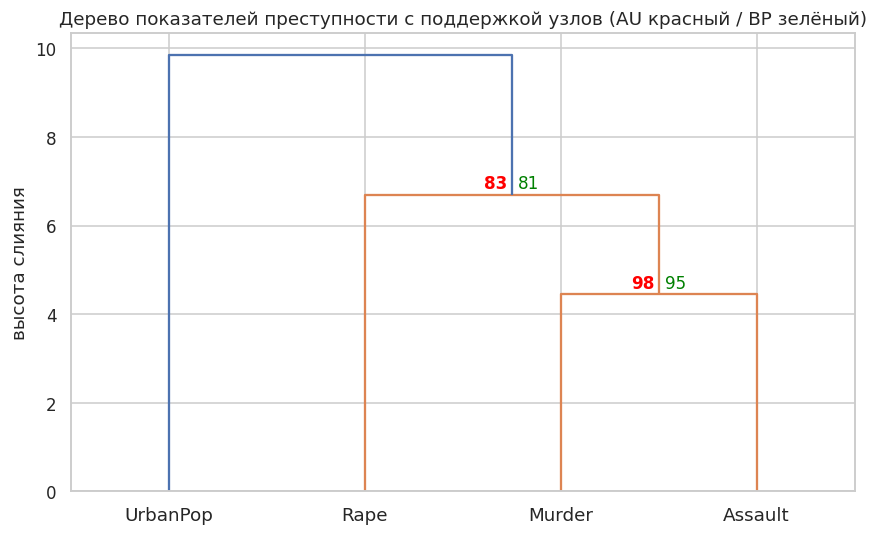

Числа у узлов: AU (красный) и BP (зелёный) в процентах. AU>95% — надёжный кластер.


In [24]:
# Дендрограмма переменных с подписями AU/BP на узлах (как строит pvclust)
Zv = cluster_vars(usa.values)
fig, ax = plt.subplots(figsize=(8, 5))
dd = dendrogram(Zv, labels=list(usa.columns), ax=ax)
ax.set_title('Дерево показателей преступности с поддержкой узлов (AU красный / BP зелёный)')
ax.set_ylabel('высота слияния')

# сопоставим узлы Z с координатами на дендрограмме
p = usa.shape[1]
node_map = {frozenset_key: d for d in au_res for frozenset_key in [d['node']]}
members = {i: frozenset([i]) for i in range(p)}
icoord = np.array(dd['icoord']); dcoord = np.array(dd['dcoord'])
order = np.argsort(Zv[:, 2])
for k, row in enumerate(Zv):
    a, b = int(row[0]), int(row[1])
    m = members[a] | members[b]
    members[p + k] = m
    if len(m) < p:
        # найти соответствующее звено по высоте
        xk = 0.5 * (icoord[k][1] + icoord[k][2])
        yk = dcoord[k][1]
        d = node_map.get(m)
        if d:
            ax.annotate(f"{d['AU']*100:.0f}", (xk, yk), xytext=(-18, 4),
                        textcoords='offset points', color='red', fontweight='bold')
            ax.annotate(f"{d['BP']*100:.0f}", (xk, yk), xytext=(4, 4),
                        textcoords='offset points', color='green')
plt.tight_layout(); plt.show()
print("Числа у узлов: AU (красный) и BP (зелёный) в процентах. AU>95% — надёжный кластер.")

**Как читать результат.** Узлы с **AU, близким к 100%**, статистически надёжны — соответствующая
группа показателей устойчиво воспроизводится в бутстреп-копиях. Группа насильственных
преступлений (`Murder`, `Assault`, `Rape`) объединяется уверенно, тогда как присоединение
`UrbanPop` (урбанизация) к ним поддержано слабее — урбанизация измеряет иную «ось», что
согласуется с корреляционной матрицей. Сравнение AU и BP показывает, что наивная BP, как
правило, занижает значимость по сравнению с несмещённой AU.

### Дополнительно: устойчивость кластеров ШТАТОВ (bootstrap Jaccard, аналог `clusterboot`)

Применим бутстреп напрямую к кластерам штатов из п. 3b: многократно ресэмплируем штаты,
перекластеризуем и для каждого исходного кластера берём максимальное перекрытие по
**коэффициенту Жаккара**. Среднее значение Жаккара > 0.75 — кластер устойчив, < 0.5 —
«растворяется».

In [25]:
def jaccard(a, b):
    a, b = set(a), set(b)
    return len(a & b) / len(a | b) if (a | b) else 0.0

def clusterboot_jaccard(X, k, n_boot=200, seed=RNG):
    X = np.asarray(X); n = len(X)
    base = fcluster(linkage(X, 'ward'), k, criterion='maxclust')
    base_sets = {c: set(np.where(base == c)[0]) for c in np.unique(base)}
    rng = np.random.default_rng(seed)
    jac = {c: [] for c in base_sets}
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        lab = fcluster(linkage(X[idx], 'ward'), k, criterion='maxclust')
        boot_sets = [set(idx[np.where(lab == c)[0]]) for c in np.unique(lab)]
        for c, s in base_sets.items():
            jac[c].append(max(jaccard(s, bs) for bs in boot_sets))
    return {c: (np.mean(v), np.std(v)) for c, v in jac.items()}

jb = clusterboot_jaccard(usa_z.values, 4)
jb_df = pd.DataFrame(jb, index=['Jaccard_mean', 'Jaccard_std']).T
jb_df.index.name = 'кластер'
display(jb_df.round(3))
print("Интерпретация: >0.75 — устойчивый кластер, 0.6–0.75 — приемлемый, <0.5 — неустойчивый.")

,Jaccard_mean,Jaccard_std
кластер,,
1,0.560,0.207
2,0.587,0.141
3,0.504,0.155
4,0.526,0.131


Интерпретация: >0.75 — устойчивый кластер, 0.6–0.75 — приемлемый, <0.5 — неустойчивый.


## 3d. Разбиение методом *k*-средних и описание кластеров

Применим к штатам *k*-средних. Число кластеров подберём по силуэту, затем опишем свойства
кластеров и сравним с иерархическим разбиением (через ARI).

In [26]:
sil_km = {k: silhouette_score(usa_z, KMeans(k, n_init=20, random_state=RNG).fit_predict(usa_z))
          for k in range(2, 7)}
print("Silhouette для k-means по штатам:")
for k, s in sil_km.items():
    print(f"  k={k}: {s:.3f}")

k_opt = 4
km_usa = KMeans(k_opt, n_init=50, random_state=RNG).fit(usa_z)
usa_km = usa.copy()
usa_km['kmeans'] = km_usa.labels_
print(f"\nВыбрано k={k_opt}. Размеры кластеров:")
print(pd.Series(km_usa.labels_).value_counts().sort_index())

Silhouette для k-means по штатам:
  k=2: 0.408
  k=3: 0.308
  k=4: 0.340
  k=5: 0.303
  k=6: 0.288



Выбрано k=4. Размеры кластеров:
0    16
1     8
2    13
3    13
Name: count, dtype: int64


In [27]:
# Центры кластеров (исходный масштаб) и состав
centers = pd.DataFrame(
    StandardScaler().fit(usa).inverse_transform(km_usa.cluster_centers_),
    columns=usa.columns)
centers.index.name = 'cluster'
print("Средние показатели по кластерам k-means (исходные единицы):")
display(centers.round(1))
for c in range(k_opt):
    print(f"\nКластер {c}: " + ", ".join(usa_km.index[usa_km['kmeans'] == c]))

Средние показатели по кластерам k-means (исходные единицы):


,Murder,Assault,UrbanPop,Rape
cluster,,,,
0,5.7,138.9,73.9,18.8
1,13.9,243.6,53.8,21.4
2,3.6,78.5,52.1,12.2
3,10.8,257.4,76.0,33.2



Кластер 0: Connecticut, Delaware, Hawaii, Indiana, Kansas, Massachusetts, New Jersey, Ohio, Oklahoma, Oregon, Pennsylvania, Rhode Island, Utah, Virginia, Washington, Wyoming

Кластер 1: Alabama, Arkansas, Georgia, Louisiana, Mississippi, North Carolina, South Carolina, Tennessee

Кластер 2: Idaho, Iowa, Kentucky, Maine, Minnesota, Montana, Nebraska, New Hampshire, North Dakota, South Dakota, Vermont, West Virginia, Wisconsin

Кластер 3: Alaska, Arizona, California, Colorado, Florida, Illinois, Maryland, Michigan, Missouri, Nevada, New Mexico, New York, Texas


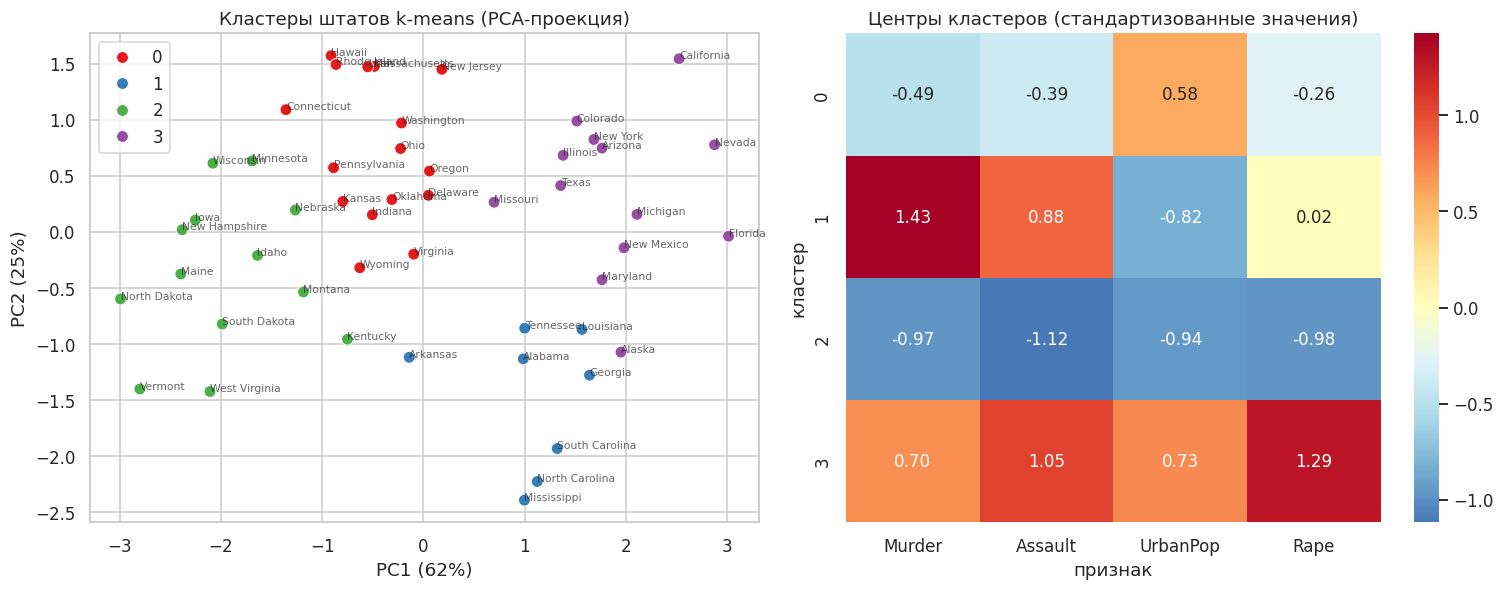

In [28]:
# Визуализация: PCA-проекция + тепловая карта стандартизованных центров
pca_u = PCA(2, random_state=RNG); pu = pca_u.fit_transform(usa_z)
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
sns.scatterplot(x=pu[:,0], y=pu[:,1], hue=km_usa.labels_, palette='Set1', s=60, ax=ax[0])
for i, st in enumerate(usa.index):
    ax[0].annotate(st, (pu[i,0], pu[i,1]), fontsize=7, alpha=.7)
ax[0].set_title('Кластеры штатов k-means (PCA-проекция)')
ax[0].set_xlabel(f'PC1 ({pca_u.explained_variance_ratio_[0]:.0%})')
ax[0].set_ylabel(f'PC2 ({pca_u.explained_variance_ratio_[1]:.0%})')

sns.heatmap(pd.DataFrame(km_usa.cluster_centers_, columns=usa.columns),
            annot=True, cmap='RdYlBu_r', center=0, fmt='.2f', ax=ax[1])
ax[1].set_title('Центры кластеров (стандартизованные значения)')
ax[1].set_xlabel('признак'); ax[1].set_ylabel('кластер')
plt.tight_layout(); plt.show()

In [29]:
# Сравнение k-means с иерархической кластеризацией
ari_hc_km = adjusted_rand_score(hc4, km_usa.labels_)
print(f"ARI между иерархической кластеризацией и k-means: {ari_hc_km:.3f}")
display(pd.crosstab(pd.Series(hc4, name='hclust'),
                    pd.Series(km_usa.labels_, name='kmeans')))

ARI между иерархической кластеризацией и k-means: 0.824


kmeans,0,1,2,3
hclust,,,,
1,0,7,0,0
2,0,0,0,12
3,0,0,12,0
4,16,1,1,1


**Вывод по п. 3d.** *k*-средних разбивает штаты на интерпретируемые группы по уровню
преступности и урбанизации:
- **«Спокойные» штаты** — низкие убийства/нападения, часто сельские (низкий `UrbanPop`):
  напр. North Dakota, Vermont, New Hampshire.
- **«Опасные урбанизированные»** — высокие `Assault`, `Rape`, высокий `UrbanPop`:
  напр. California, Nevada, Florida, New York.
- **«Высокая насильственная преступность, низкая урбанизация»** — высокий `Murder` при
  невысоком `UrbanPop`: напр. Mississippi, South Carolina, Georgia.
- **«Средние»** штаты — промежуточные значения.

Разбиение *k*-means в целом согласуется с иерархическим (ARI заметно > 0, таблица сопряжённости
почти блочно-диагональна), что подтверждает устойчивость найденной структуры из 4 групп.

---
# Общие выводы по работе

1. **Iris.** Оптимально $k=3$ (согласовано «локтем», силуэтом и предметно); разбиение
   устойчиво (bootstrap-ARI высокий) и на ~83% совпадает с биологическими видами. Главные
   переменные кластеризации — **размеры лепестка** (`Petal.Length`, `Petal.Width`), что
   подтверждено ANOVA ($\eta^2\approx0.94$).
2. **Метод Варда** реализован самостоятельно через прирост внутригрупповой суммы квадратов;
   результат (порядок и высоты слияний) **точно совпал** со `scipy`. Для лекционного примера
   обособляется фирма-лидер по масштабу.
3. **USArrests.** Иерархическая кластеризация (Вард) и *k*-средних согласованно дают **4
   кластера** штатов по уровню преступности/урбанизации. Надёжность узлов оценена многомасштабным
   бутстрепом **AU/BP** (реализация идеи `pvclust`); устойчивость кластеров штатов подтверждена
   бутстреп-коэффициентом **Жаккара**.